In [1]:
import os
import re
from typing import Optional
from fractions import Fraction

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# paths of raw data files provided by competition host
PUBLISHED_TEXTS_CSV_PATH = os.path.join("data", "published_texts.csv")
TRAIN_CSV_PATH = os.path.join("data", "train.csv")

# paths of output files
CLEANED_DATA_PATH = os.path.join("data", "cleaned_train_data.csv")

# EDA

The competition host provides three files:
- `train.csv`: 1561 transliteration-translation pairs
- `published_texts.csv`: ~8000 transliteration text
- `Sentences_Oare_FirstWord_LinNum.csv`: instructions on how to split texts into sentences

`published_texts.csv` contains the largest collection of corpus.

In [3]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
sentence_align_df = pd.read_csv("data/Sentences_Oare_FirstWord_LinNum.csv")
published_texts_df = pd.read_csv(PUBLISHED_TEXTS_CSV_PATH)

In [4]:
uuid_in_train = set(train_df['oare_id'].unique())
uuid_in_published_texts_df = set(published_texts_df['oare_id'].unique())
uuid_in_sentence_file = set(sentence_align_df['text_uuid'].unique())

print(f"Is `train.csv` a proper subset of `published_texts.csv'? {uuid_in_train.issubset(uuid_in_published_texts_df)}")
print(f'Num of train texts that have sentence-level splitting available: {len(uuid_in_train.intersection(uuid_in_sentence_file))}')
print(f'Num of published texts that have sentence-level splitting available: {len(uuid_in_published_texts_df.intersection(uuid_in_sentence_file))}')

Is `train.csv` a proper subset of `published_texts.csv'? True
Num of train texts that have sentence-level splitting available: 253
Num of published texts that have sentence-level splitting available: 1417


In [5]:
only_in_sentence_align = uuid_in_sentence_file-uuid_in_published_texts_df
print(f'There are {len(only_in_sentence_align)} texts that have sentence-level splitting, but not in `published_texts.csv`')
sentence_align_df[sentence_align_df['text_uuid'].isin(only_in_sentence_align)]

There are 283 texts that have sentence-level splitting, but not in `published_texts.csv`


,display_name,text_uuid,sentence_uuid,sentence_obj_in_text,translation,first_word_transcription,first_word_spelling,first_word_number,first_word_obj_in_text,line_number,side,column
33,(LB 1206),51e95806-26be-4ac8-b229-1643c1d217be,8d0e6c76-ecfb-4068-bd0e-516489e8241d,3,From Šalim-aḫum to Pūšu-kēn:,NaN,um-ma,1,5,1.0,1,1
34,(LB 1206),51e95806-26be-4ac8-b229-1643c1d217be,88e4e48c-017b-472a-9e12-6aa6e31a44e3,12,Your tablet came up and concerning the roughly...,NaN,ṭup-pá-kà,6,14,2.0,1,1
35,(LB 1206),51e95806-26be-4ac8-b229-1643c1d217be,4e97e8d4-e77e-4512-89be-798cc06c6aa9,48,You wrote.,NaN,ta-áš-pu-ra-am,31,49,8.0,1,1
36,(LB 1206),51e95806-26be-4ac8-b229-1643c1d217be,d3f8b7f5-452f-496b-9fe2-d981fb8c9b63,82,"While he had arrived, I did not sell anything ...",NaN,a-dí,56,84,14.0,1,1
37,(LB 1229),d9f86f1c-878b-4fe7-9508-bcafd3360766,33391bfe-6f70-4662-950a-c9fadffec234,3,From Šalim-aḫum to Pūšu-kēn:,NaN,um-ma,1,5,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7318,Kt v/k 22,690df305-902f-bee4-911a-04ab8a358b5b,06403416-61d1-4cfa-8375-b77ef5215f57,221,1 talent which you sent to the merchant arrive...,errabma,e-ra-ab-ma,135,223,34.0,4,1
7319,Kt v/k 22,690df305-902f-bee4-911a-04ab8a358b5b,21207c90-9d09-40dd-89e0-2800a2ad64a6,240,"From the textiles, therein 8 textiles as wrapp...",ina,i-na,145,242,38.0,5,1
7320,Kt v/k 22,690df305-902f-bee4-911a-04ab8a358b5b,16f7a394-1b0b-460a-8121-d097cf754c41,257,The excise duty was 2 textiles.,ṣubātū,TÚG,157,260,39.0,5,1
7321,Kt v/k 22,690df305-902f-bee4-911a-04ab8a358b5b,10f3a7ca-9df0-4570-a73c-5124b5a1f7b2,262,"Then, you are repaying 1 shekel silver.",u,ù,159,263,40.0,5,1


Do a raw inspection on the length of texts (num of token). Most texts are less than 200 words long.

shortest text: 1, longest text: 613


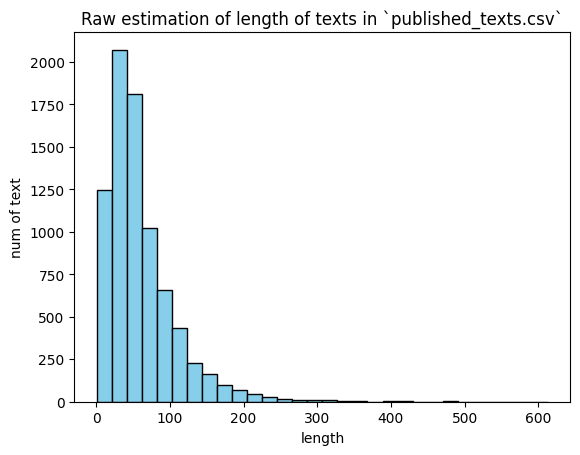

In [6]:
def count_num_token_raw(text):
    return len([w for w in text.split() if w not in {'x', 'xx', 'xxx', '.', '...', '…'}])

num_token_raw = published_texts_df['transliteration'].apply(count_num_token_raw)
print(f'shortest text: {num_token_raw.min()}, longest text: {num_token_raw.max()}')

plt.hist(num_token_raw, bins=30, color='skyblue', edgecolor='black') 

plt.title("Raw estimation of length of texts in `published_texts.csv`")
plt.xlabel("length")
plt.ylabel("num of text")

plt.show()


Filter out some awfully broken translations by looking at the length ratio between transliteration and translation.
Since Akkadian is morphologically complex and "a single word can encode what takes multiple words in English", I expect the English translation to be at least as long as the Akkadian text.

In [7]:
num_token_eng = train_df['translation'].apply(count_num_token_raw)
num_token_akk = train_df['transliteration'].apply(count_num_token_raw)
eng_akk_len_ratio = num_token_eng/num_token_akk

train_df[eng_akk_len_ratio < 1]

,oare_id,transliteration,translation
16,02d16b63-3fab-4c1d-8262-4cd74f6532f1,9 GÍN AN.NA e-lu-ḫu-ut 10 GÍN AN.NA ú šál-ša-t...,9 shekels of tin: Eluhut;
20,0309d067-0bb7-40f6-9d27-1dfb0c60e507,23.5 GÚ SÍG.ḪI.A 66 maš-ku 10 ANŠE ṣa-lá-mu ú ...,"23.5 talents of wool, 66 fleeces, 10 black don..."
21,035670c1-3504-4084-a2e6-1ff68ade4c74,[...] ša-lim-ar-dí ú šu-nu-nu áp-qí-id IGI a-š...,... I entrusted to Šalim-wardī and Šu-Nūnu. Wi...
35,054fdba4-0cff-4153-969d-c77e42413e1c,0.5 ma-na a be-a-lim a-na ú-ṣú-ur-ša-a-šur DUM...,0.5 mina for a working capital to Uṣur-ša-Aššu...
40,06a9a456-58e2-4fed-9687-913d824cadc4,i-na 48 ku-ta-ni ša ik-ri-bi ŠÀ.BA 5 ku-ta-ni ...,Of the 48 kutānus of the votive offerings: 5 k...
...,...,...,...
1497,f5fd2519-33d6-4a46-9423-59a32b151e88,1 me-at (TÚG)ku-ta-ni 4 GÚ AN.NA ù it-ra-sú 5 ...,"As to the 100 kutānu-textiles, 4 talents of ti..."
1534,faf96b3b-a1d8-462d-bb3e-0e3875d07daa,3 GÚ URUDU ma-as-am ku-nu-ki-a a-ḫa-ma 20 ma-n...,"3 talents of washed copper under my seal, and ..."
1539,fc15e06d-312d-4f77-87f2-7004dd734d6a,0.5 ma-na sí-pá-ra-tim i li-bi₄-i PUZUR₄-a-šùr...,0.5 mina of bronze pins is owed by Puzur-Aššur.
1543,fcf5a0e5-2a2f-4651-8b46-5e860167dc10,0.83333 ma-na KÙ.BABBAR PUZUR₄-a-šùr il₅-qé 0....,Puzur-Aššur received 0.83333 minas of silver; ...


Many of these translations are indeed not complete

In [8]:
train_df['translation_suscpicious'] = eng_akk_len_ratio < 1
train_df.head()

,oare_id,transliteration,translation,translation_suscpicious
0,004a7dbd-57ce-46f8-9691-409be61c676e,KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-(d)IM KIŠI...,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ...",False
1,0064939c-59b9-4448-a63d-34612af0a1b5,1 TÚG ša qá-tim i-tur₄-DINGIR il₅-qé,Itūr-ilī has received one textile of ordinary ...,False
2,0073f2c0-524c-4bbf-915a-8c1772a4fb98,TÚG u-la i-dí-na-ku-um i-tù-ra-ma 9 GÍN KÙ.BABBAR,... he did not give you a textile. He returned...,False
3,009fb838-8038-42bc-ad34-5f795b3840ee,KIŠIB šu-(d)EN.LÍL DUMU šu-ku-bi-im KIŠIB ṣí-l...,"Seal of Šu-Illil son of Šu-Kūbum, seal of Ṣilū...",False
4,00aa1c55-c80c-4346-a159-73ad43ab0ff7,um-ma šu-ku-tum-ma a-na IŠTAR-lá-ma-sí ù ni-ta...,From Šukkutum to Ištar-lamassī and Nitahšušar:...,False


# Data Normalization

In [9]:
train_pubtext_df = pd.merge(
    left=published_texts_df[['oare_id', 'transliteration_orig']], 
    right=train_df[['oare_id','translation', 'translation_suscpicious']], 
    how="left", 
    on='oare_id'
)
train_pubtext_df.head()

,oare_id,transliteration_orig,translation,translation_suscpicious
0,bd4b7138-70d5-490d-8234-299b0a75d3a3,KIŠIB a-šùr-ma-lik DUMU i-na-a a-na a-šùr-na-d...,NaN,NaN
1,b05376c2-fc3d-49f8-9792-a25c0df9c383,0.33333 ma-na 7 GÍN KÙ.BABBAR ṣa-ru-pá-am i-ṣé...,NaN,NaN
2,80547963-f2a2-4d5d-9544-fc7ada60d3b2,{large break} a-na a-lá-lá-ma-sí ù a-mur-DINGI...,NaN,NaN
3,8c0d4238-f795-4061-8b3c-8469a66d86d6,um-ma PUZUR₄-a-šùr-ma a-na bu-za-zu qí-bi-ma a...,NaN,NaN
4,2c0d870b-cd5e-fc36-8d81-114ecc7a9ac4,bu-za-zu il₅-we-da-ku iš-a-al-ma um-ma bu-za-z...,NaN,NaN


### Normalize special characters

In [10]:
class SpecialCharacterNormalizer:
    """
    Class for normalizing special characters in Akkadian and English text
    It mainly normalizes these:
    1. subscripts 
    2. gap representation
    3. fraction numbers
    4. determinatives
    """
    def __init__(self):

        # determinatives
        self.determinative_mapping = {
            '{d}': ['ᵈ', r'\{d\}', r'\(d\)', r'\{ᵈ\}', r'\(ᵈ\)'],
            '{mul}': ['ᵐᵘˡ', 'ᴹᵁᴸ', r'\{mul\}', r'\(mul\)', r'\{ᵐᵘˡ\}', r'\(ᵐᵘˡ\)',r'\{ᴹᵁᴸ\}', r'\(ᴹᵁᴸ\)'],
            '{ki}': ['ᴷᴵ', 'ᵏⁱ', r'\{ki\}', r'\(ki\)', r'\{ᴷᴵ\}', r'\(ᴷᴵ\)',r'\{ᵏⁱ\}', r'\(ᵏⁱ\)'],
            '{lú}': [r'\{lú\}', r'\(lú\)', r'\{lu2\}', r'\(lu2\)', r'\{lu₂\}', r'\(lu₂\)'],
            '{é}': [r'\{é\}', r'\(é\)', r'\{e2\}', r'\(e2\)', r'\{e₂\}', r'\(e₂\)'],
            '{uru}': ['ᵁᴿᵁ', 'ᵘʳᵘ', r'\{ᵁᴿᵁ\}', r'\(ᵁᴿᵁ\)', r'\{ᵘʳᵘ\}', r'\(ᵘʳᵘ\)', r'\{uru\}', r'\(uru\)'],
            '{kur}': ['ᴷᵁᴿ', 'ᵏᵘʳ', r'\{ᴷᵁᴿ\}', r'\(ᴷᵁᴿ\)', r'\{ᵏᵘʳ\}', r'\(ᵏᵘʳ\)', r'\{kur\}', r'\(kur\)'],
            '{mi}': ['ᶠ', r'\{mi\}', r'\(mi\)', r'\{ᶠ\}', r'\(ᶠ\)'],
            '{m}': ['¹', 'ᵐ', r'\{m\}', r'\(m\)', r'\{ᵐ\}', r'\(ᵐ\)'],
            '{geš}': [r'\{geš\}', r'\(geš\)', r'\{GIŠ\}', r'\(GIŠ\)',r'\{ĝeš\}', r'\(ĝeš\)'],
            '{túg}': [r'\{tug2\}', r'\(tug2\)', r'\{tug₂\}', r'\(tug₂\)',r'\{túg\}', r'\(túg\)', r'\{TÚG\}',r'\(TÚG\)'],
            '{dub}': ['ᴰᵁᴮ', r'\{dub\}', r'\(dub\)', r'\{ᴰᵁᴮ\}', r'\(ᴰᵁᴮ\)'],
            '{íd}': [r'\{íd\}', r'\(íd\)'],
            '{mušen}': [r'\{MUŠEN\}', r'\(MUŠEN\)'],
            '{na4}': ['ⁿᵃ⁴', r'\{na4\}', r'\(na4\)', r'\{ⁿᵃ⁴\}', r'\(ⁿᵃ⁴\)'],
            '{kuš}': [r'\{kuš\}', r'\(kuš\)'],
            '{ú}': [r'\{u2\}', r'\(u2\)', r'\{u₂\}', r'\(u₂\)',r'\{ú\}', r'\(ú\)', r'\{Ú\}', r'\(Ú\)']
        }
        
        self.determinative_regexes = {}
        for standard_form, variants in self.determinative_mapping.items():
            combined_pattern = '|'.join(variants) 
            self.determinative_regexes[standard_form] = re.compile(combined_pattern, re.IGNORECASE) # ignore case


        # diacritics
        self.diacritic_mapping = {
            'sz': 'š', # convert ASCII substitutes (e.g., sz) into diacritics
            'SZ': 'Š',
            'ṣ': 'ṣ',  # keep diacritics
            'ṭ': 'ṭ',
            'Š': 'Š',
            'š': 'š',
            'Ṣ': 'Ṣ',
            'ṭ': 'ṭ',
            'Ṭ': 'Ṭ'
        }

        self.vowel_diacritic_map = {
            'a': {'2': 'á', '3': 'à'}, # e.g. a2 -> á
            'e': {'2': 'é', '3': 'è'},
            'i': {'2': 'í', '3': 'ì'},
            'o': {'2': 'ó', '3': 'ò'},
            'u': {'2': 'ú', '3': 'ù'},
            'A': {'2': 'Á', '3': 'À'},
            'E': {'2': 'É', '3': 'È'},
            'I': {'2': 'Í', '3': 'Ì'},
            'O': {'2': 'Ó', '3': 'Ò'},
            'U': {'2': 'Ú', '3': 'Ù'}
        }

        # subscripts
        self.subscript_to_plain_map = {
            '₀': '0', '₁': '1', '₂': '2', '₃': '3', '₄': '4',
            '₅': '5', '₆': '6', '₇': '7', '₈': '8', '₉': '9'
        }
        self.any_subscript_regex = re.compile(r'[' + ''.join(self.subscript_to_plain_map.keys()) + ']+')
        
        # Gap normalization
        # e.g. […]、[……]、[… …]、[… … …] 
        self.bracketed_big_gap_regex = re.compile(r'(\[\s*(\…\s*)+\s*\])|(\[\s*(\.\s*){3,}\s*\])')
        self.large_break_regex = re.compile(r'\{\s*large break\s*\}')
        # e.g. …、……、………
        self.plain_big_gap_regex = re.compile(r'(\…+)|(x{2,})|(\.{3,})')
        # e.g. [x]
        self.small_gap_regex = re.compile(r'\[\s*x\s*\]')
        # e.g. x
        self.plain_small_gap_regex = re.compile(r'\bx\b')

        
        # remove invalid characters
        self.invalid_patterns = {
            # NOTE: this is the last step (before cleaning extra space)
            "akkadian": [
                r'[\[!?\\˹˺\]]',
                r'\s+[.:]\s+', # word dividers that have spaces on both sides
            ],
            "english": [
                r'\(\s*(fem\.\s*sing\.|fem\.\s*plur\.|fem\.\s*pl\.|plural|plur\.|fem\.|fem|pl\.|pl|sing\.|sing)\s*\)',
                r'[\[\(\\˹˺\]\)]',
                r'\(\s*[?!]\s*\)',
                r'\s+[.:]\s+', # word dividers that have spaces on both sides
            ]

        }
        self.invalid_regex = {lang:re.compile('|'.join(self.invalid_patterns[lang])) for lang in self.invalid_patterns}

        self.fraction_lookup = {
            (1, 2): "½", 
            (1, 3): "⅓", (2, 3): "⅔",
            (1, 4): "¼", (3, 4): "¾",
            (1, 5): "⅕", (2, 5): "⅖", (3, 5): "⅗", (4, 5): "⅘",
            (1, 6): "⅙", (5, 6): "⅚",
            (1, 7): "⅐", 
            (1, 8): "⅛", (3, 8): "⅜", (5, 8): "⅝", (7, 8): "⅞",
            (1, 9): "⅑", 
            (1, 10): "⅒",
        }
        
        # some occasional bad cases
        self.special_cases = [
            {"wrong": re.compile(r'='), "correct": "-"}
        ]
        
        

    def clean_single_text(self, text: str, language: str="akkadian") -> Optional[str]:
        """
        Main method
        """
        if not isinstance(text, str) or text.strip() == "":
            return None
        
        if language == "akkadian":
            text = self._normalize_determinatives(text)
            text = self._normalize_gap_markers(text)
            text = self._merge_consecutive_gap(text)
            text = self._normalize_vowel_diacritic(text)
            text = self._normalize_fractions(text)
            text = self._remove_invalid_strings(text)
            text = self._clean_extra_spaces(text)
        elif language == "english":
            text = self._normalize_gap_markers(text)
            text = self._merge_consecutive_gap(text)
            text = self._normalize_fractions(text)
            text = self._remove_invalid_strings(text, lang = 'english')
            text = self._clean_extra_spaces(text)
        
        if not text or text.strip() == "":
            return None
        
        return text

    def _remove_invalid_strings(self, text: str, lang:str = "akkadian") -> str:
        if not isinstance(text, str):
            return ""

        for special_case in self.special_cases:
            text = special_case['wrong'].sub(special_case['correct'], text)

        # remove the ?! in e.g. "(abc ?)" in translation text
        def _remove_punctuation_in_parenthesis(match):
            left_bracket = match.group(1)
            inner = match.group(2) + match.group(3)
            right_bracket = {'(': ')', '<': '>', '[': ']', '{': '}'}[left_bracket]
            return f'{left_bracket}{inner}{right_bracket}'
        
        if lang != "akkadian":
            text = re.sub(r'([\(\[\{])([^\]\)}]*?)[?!]([^\]\)}]*)[\]\)}]', _remove_punctuation_in_parenthesis, text)
        
        # remove all the invalid characters
        text = self.invalid_regex[lang].sub('', text)

        # special case: "<xxx>" -> "xxx" EXCEPT for <gap> and <big_gap>
        def _transform_angle_brackets(match):
            content = match.group(1)  
            if content.lower() in ['gap', 'big_gap']:
                return match.group(0)  
            return content
        
        text = re.sub(r'<([^>]+)>', _transform_angle_brackets, text)
        
        return text
    
    def _normalize_determinatives(self, text: str) -> str:

        if not isinstance(text, str):
            return ""
        
        for standard_form, regex in self.determinative_regexes.items():
            text = regex.sub(standard_form, text)
        
        return text

    def _normalize_gap_markers(self, text: str) -> str:
        """
        Normalize gap markers to <gap>/<big_gap>
        1. […]/[……]/[… …]/…/……  -> <big_gap>
        2. [x]/x -> <gap>
        """
        if not isinstance(text, str):
            return ""
        
        text = self.bracketed_big_gap_regex.sub('<big_gap>', text)
        text = self.large_break_regex.sub('<big_gap>', text)
        text = self.plain_big_gap_regex.sub('<big_gap>', text)
        
        text = self.small_gap_regex.sub('<gap>', text)
        text = self.plain_small_gap_regex.sub('<gap>', text)
        
        return text
    
    def _convert_all_subscripts_to_plain(self, text: str) -> str:
        """
        Convert all numerical subscripts to normal number
        ₅ -> 5, ₁₀ -> 10, ₁₂₃ -> 123
        """
        if not isinstance(text, str):
            return ""
        
        def _replace_subscript_group(match):
            subscript_group = match.group(0)
            plain_digits = ''.join([self.subscript_to_plain_map[char] for char in subscript_group])
            return plain_digits
        
        text = self.any_subscript_regex.sub(_replace_subscript_group, text)
        return text

    def _normalize_vowel_diacritic(self, text: str) -> str:
        """
        1. handle subscripts: ₂ or ₃ -> diacritics, others-> normal numbers
        2. ASCII substitutes -> diacritics, e.g. sz -> š
        """
        text = self._convert_all_subscripts_to_plain(text)

        if not isinstance(text, str):
            return ""

        # find single 2/3
        def _vowel_to_diacritic(match):
            vowel_char = match.group(1)  
            num = match.group(2)         
            return self.vowel_diacritic_map.get(vowel_char, {}).get(num, f"{vowel_char}{num}")
        
        text = re.sub(r'([aeiouAEIOU])([23])(?![0-9])(?![0-9])', _vowel_to_diacritic, text)
        
        for old_str, new_str in self.diacritic_mapping.items():
            text = text.replace(old_str, new_str)
        
        return text
    
    def _normalize_fractions(self, text: str) -> str:
        """
        Normalizes decimal and slash-represented fraction number to unicode fraction
        """
        
        if not isinstance(text, str):
            return ""
        
        def _replace_str_with_decimal_point(match):
            
            full_str = match.group(0)
            try:
                val = float(full_str)
                integer_part = int(val)
                decimal_part = val - integer_part
                # return integer if decimal is negligible
                if decimal_part < 0.0001: 
                    return str(integer_part)
                # limit denominator handles 0.3333 -> 1/3
                frac = Fraction(decimal_part).limit_denominator(12) 

                unicode_frac = self.fraction_lookup.get((frac.numerator, frac.denominator))
                if unicode_frac:
                    if integer_part == 0:
                        return unicode_frac
                    else:
                        # Current logic: Space between Integer and Fraction
                        return f"{integer_part} {unicode_frac}"

                return full_str 
            except ValueError:
                return full_str
        
        def _replace_str_with_fraction_slash(match):
            full_str = match.group(0)
            frac = Fraction(full_str).limit_denominator(12) 

            return self.fraction_lookup.get((frac.numerator, frac.denominator), full_str)

        text = re.sub(r'\b\d+\.\d+\b', _replace_str_with_decimal_point, text) # 1.3333 -> 1 ⅓
        text = re.sub(r'\d+\s*/\s*\d+', _replace_str_with_fraction_slash, text) # 1 / 3  -> ⅓
        return text
        

    def _merge_consecutive_gap(self, text: str) -> str:
        if not isinstance(text, str):
            return ""

        pattern = r'\s+(?:<gap>|<big_gap>)(?:\s+(?:<gap>|<big_gap>))+\s+'

        text_with_padding = f' {text} ' # trick to identify <gap> or <big_gap> that is the first word of the text 
        text = re.sub(pattern, " <big_gap> ", text_with_padding).strip()

        return text
    
    def _clean_extra_spaces(self, text: str) -> str:

        if not isinstance(text, str):
            return ""
        
        # { d }→{d}、{ lu }→{lu}
        text = re.sub(r'{\s*', '{', text)
        text = re.sub(r'\s*}', '}', text)
        
        # if there are spaces between - and <gap>, remove the spaces
        # e.g. change "<gap> -A-šùr" to  "<gap>-A-šùr"
        text = re.sub(r'<(gap|big_gap)>\s+(?=-)', r'<\1>', text)
        text = re.sub(r'(?<=-)\s+<(gap|big_gap)>', r'<\1>', text)
        
        # "    " -> " "
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text

In [11]:
akkadian_test_data = [
    {"original": "i-si₂-ba-at", "expected": "i-sí-ba-at"},
    {"original": "KU₃-pi₃-a", "expected": "KÙ-pì-a"},
    {"original": "KISZIB", "expected": "KIŠIB"},
    {"original": "DU₁₀", "expected": "DU10"},
    {"original": "[KÙ.BABBAR]", "expected": "KÙ.BABBAR"},

    # merge gaps
    {
        "original": "(d)IŠKUR-<gap> <gap> <gap> <big_gap> <gap>-yyy", 
        "expected": "{d}IŠKUR-<gap> <big_gap> <gap>-yyy"
     },
    {
        "original": "x x x x x x x x x x x x ni x x x x x x x im ú-šé-bi-lá-ni a-na ma-la na-áš-pé-er-tim ša x-…",
        "expected": "<big_gap> ni <big_gap> im ú-šé-bi-lá-ni a-na ma-la na-áš-pé-er-tim ša <gap>-<big_gap>"
    },
    
    
    # replace  x or [x] with <gap>
    {"original": "x x-mì (d)IŠKUR ší-im šu-mì-x DINGIR", "expected": "<gap> <gap>-mì {d}IŠKUR ší-im šu-mì-<gap> DINGIR"},
    {"original": "xxx DINGIR", "expected":"<big_gap> DINGIR"},
    {"original": "… x … pu-šu-ke-en₆ xxxx-šu ŠU.NÍGIN 42.33333 ma-na KÙ.BABBAR … ub-lá-ku-um 18 ma-na KÙ.BABBAR ni-is-ḫa-sú LÁ DIRI 18 GÍN ša-du-a-sú ša-bu ku-nu-ki-a ù ku-nu-uk la-li-im kur-ub-IŠTAR na-áša-kum-A ki-ma la-qé-pí-im la-lu-um ik-nu-uk ŠU.NÍGIN 2 GÚ 27 ma-na 10 8 GÍN KÙ.BABBAR iš-tù a-li-kà-ni i-li-kà-kum me-eḫ-ra-am i ku-nu-uk la-qé-pí-im kà-an-ku-ma za-ku-sà lá-áš-pu-ra-kum i-na KÙ.BABBAR-pí-kà ša u₄-me … x … ù ṣú-ba-tí-kà i-ta-ba-al iš-tù tur₄-ḫu-mi-it a-ša-sú-ḫi-šu áš-ta-pár … x-pu-ul šu-ma mì-ma a-na … x a-ma-ga-ar", 
     "expected":"<big_gap> pu-šu-ke-en6 <big_gap>-šu ŠU.NÍGIN 42 ⅓ ma-na KÙ.BABBAR <big_gap> ub-lá-ku-um 18 ma-na KÙ.BABBAR ni-is-ḫa-sú LÁ DIRI 18 GÍN ša-du-a-sú ša-bu ku-nu-ki-a ù ku-nu-uk la-li-im kur-ub-IŠTAR na-áša-kum-A ki-ma la-qé-pí-im la-lu-um ik-nu-uk ŠU.NÍGIN 2 GÚ 27 ma-na 10 8 GÍN KÙ.BABBAR iš-tù a-li-kà-ni i-li-kà-kum me-eḫ-ra-am i ku-nu-uk la-qé-pí-im kà-an-ku-ma za-ku-sà lá-áš-pu-ra-kum i-na KÙ.BABBAR-pí-kà ša u4-me <big_gap> ù ṣú-ba-tí-kà i-ta-ba-al iš-tù tur4-ḫu-mi-it a-ša-sú-ḫi-šu áš-ta-pár <big_gap> <gap>-pu-ul šu-ma mì-ma a-na <big_gap> a-ma-ga-ar"},
    {"original": "KÙ.BABBAR lu-ta-e-ru-nim na-áš-pá-ar-ti ḫa-na-a i-li-kam a-mur-a-šur [x] KÙ.BABBAR x", "expected": "KÙ.BABBAR lu-ta-e-ru-nim na-áš-pá-ar-ti ḫa-na-a i-li-kam a-mur-a-šur <gap> KÙ.BABBAR <gap>"},
    # replace … with <big_gap>
    {"original": " <gap> um-ma …-a-šur-ma a-na [……]-lim-ma lu [… …] ", "expected": "<gap> um-ma <big_gap>-a-šur-ma a-na <big_gap>-lim-ma lu <big_gap>"},
    # replace <large break> with <big_gap>
    {"original": "{large break} KIŠIB ú-x … ší-im ṣú-ḫa-ri-im … ù tí-sà-pu-um x … {large break} … x-ni i-ša-x …", "expected": "<big_gap> KIŠIB ú-<gap> <big_gap> ší-im ṣú-ḫa-ri-im <big_gap> ù tí-sà-pu-um <big_gap> <gap>-ni i-ša-<gap> <big_gap>"},

    # special case: - recognized as =
    {"original": "1 ma-na KÙ.GI ša šu-la-ba-an ši-ip-kà-at me-ra-lí qá-dí-ma na-ru-qí-šu ša … a-lim{ki} … x-iš … en-um={d}IŠKUR … kur-ub-IŠTAR",
     "expected": "1 ma-na KÙ.GI ša šu-la-ba-an ši-ip-kà-at me-ra-lí qá-dí-ma na-ru-qí-šu ša <big_gap> a-lim{ki} <big_gap> <gap>-iš <big_gap> en-um-{d}IŠKUR <big_gap> kur-ub-IŠTAR"}
]   

atc = SpecialCharacterNormalizer()
all_passed = True
for t in akkadian_test_data:
    actual = atc.clean_single_text(t['original'])
    if actual != t['expected']:
        all_passed = False
        print(f"Unmatched result found for: {t['original']}\nExpected:{t['expected']}\nActual:{actual}")
        print("=="*10)
    #print(atc.clean_single_text(t['original']))

if all_passed:
    print("All Passed!")

All Passed!


In [12]:
english_text_data = [
    {
        'original': "30 minas of refined silver, its excise added, his transport fee paid, under <my> seals, I entrusted to Ennam-Aššur, son of Uṣāriya, in the presence of Puzur-Adad, son of ..., and of Kurub-Ištar.",
        'expected': "30 minas of refined silver, its excise added, his transport fee paid, under my seals, I entrusted to Ennam-Aššur, son of Uṣāriya, in the presence of Puzur-Adad, son of <big_gap>, and of Kurub-Ištar."
    },
    {
        'original': "7 shekels of [silver] I gave him for his expenses. 15 minas of silver, its excise added, his transport fee paid, under my seal, I entrusted to Adad-pilah, son of Anīnum, in the presence of Šu-Ištar, son of Šukutum, and of Aššur-mālik, son of Šabahānum. 30 minas of refined silver, its excise added, his transport fee paid, under my seal, I entrusted to Aššur-rē'ī, son of Iddin-Ištar, in the presence of Šu-Kūbum, son of Uzua, and of the son of Kurub-Ištar, son of [Amurrum-bāni; 3 shekels of silver I gave for his expenses." ,
        'expected': "7 shekels of silver I gave him for his expenses. 15 minas of silver, its excise added, his transport fee paid, under my seal, I entrusted to Adad-pilah, son of Anīnum, in the presence of Šu-Ištar, son of Šukutum, and of Aššur-mālik, son of Šabahānum. 30 minas of refined silver, its excise added, his transport fee paid, under my seal, I entrusted to Aššur-rē'ī, son of Iddin-Ištar, in the presence of Šu-Kūbum, son of Uzua, and of the son of Kurub-Ištar, son of Amurrum-bāni; 3 shekels of silver I gave for his expenses."
    },
    {
        'original': "25 shekels of silver [his working capital?], 10 shekels for the road-tax of your servant ... 7 shekels of silver for Šu-... he paid to Barānum. ",
        'expected': "25 shekels of silver his working capital, 10 shekels for the road-tax of your servant <big_gap> 7 shekels of silver for Šu-<big_gap> he paid to Barānum."
    },
    {
        'original': "In all 42 shekels of silver, its excise added, for En[nam-Aššur]. ",
        'expected': "In all 42 shekels of silver, its excise added, for Ennam-Aššur."
    },
    {
        'original': "10 shekels of silver, its excise added, for Pilah-Ištar, son of I[bisu'a]; 27 shekels of silver, the price [of 2 textiles of his] for Dadiya; 27 [shekels of silver], the price of 2 textiles of his for En[nam-Aššur]; 52 shekels of silver, the price [of 4 textiles of his for Aššur-rēṣī; one bundle with 25 shekels of silver for Aššur-kašid, Šu-Suen and Aššur-idī I [added]; 19 shekels of silver for Aššur-rē'ī; 0.5 mina of silver of Lamassutum ..., being temple property of [? ...]; 10 shekels of silver, consignment for Ummī-Išhara; [x silver?] for Ilī-uṣ[ranni]; 4 shekels of silver of [...] for Ummī-Išhara; 1.6666 shekel of silver of Lamassutum for [Ummī-Išhara; 1 shekel of silver for Bēlulu; 1 shekel of [silver for Nar'amtum; 1 shekel of silver for Buṣū; 0.5 shekel of [silver for ME-labrat. All this, under my seals, I entrusted to Aššur-rē'ī and he brought it away to the City.",
        'expected': "10 shekels of silver, its excise added, for Pilah-Ištar, son of Ibisu'a; 27 shekels of silver, the price of 2 textiles of his for Dadiya; 27 shekels of silver, the price of 2 textiles of his for Ennam-Aššur; 52 shekels of silver, the price of 4 textiles of his for Aššur-rēṣī; one bundle with 25 shekels of silver for Aššur-kašid, Šu-Suen and Aššur-idī I added; 19 shekels of silver for Aššur-rē'ī; ½ mina of silver of Lamassutum <big_gap>, being temple property of <big_gap>; 10 shekels of silver, consignment for Ummī-Išhara; <gap> silver for Ilī-uṣranni; 4 shekels of silver of <big_gap> for Ummī-Išhara; 1 ⅔ shekel of silver of Lamassutum for Ummī-Išhara; 1 shekel of silver for Bēlulu; 1 shekel of silver for Nar'amtum; 1 shekel of silver for Buṣū; ½ shekel of silver for ME-labrat. All this, under my seals, I entrusted to Aššur-rē'ī and he brought it away to the City."
    },
    {
        'original' : "... the death of my father has Ennam-Aššur ... the representatives of their (fem.) fathers did not ... that they did encourage the men. As for you (plur.), you did not write either about my father's death or send me your greetings to encourage me.",
        'expected' : "<big_gap> the death of my father has Ennam-Aššur <big_gap> the representatives of their fathers did not <big_gap> that they did encourage the men. As for you , you did not write either about my father's death or send me your greetings to encourage me."
    },
    {
        'original' : "[15 shekels of silver] Ennam-Aššur gave to Uṣur-<pī>-Aššur. If in the City a tablet with the seal of Uṣur-pī-Aššur <in the City> their sister Ummī-Išhara has, to the effect that he will not claim what her mother Lamassutum had inherited and what had been left behind by her, then Uṣur-pī-Aššur will give back the 15 shekels of silver. In the presence of Ēnah-ilī, of Šalim-Ištar of Aššur-[... ... ...] of Mas(s)āya, of Aššur-mālik",
        'expected' : "15 shekels of silver Ennam-Aššur gave to Uṣur-pī-Aššur. If in the City a tablet with the seal of Uṣur-pī-Aššur in the City their sister Ummī-Išhara has, to the effect that he will not claim what her mother Lamassutum had inherited and what had been left behind by her, then Uṣur-pī-Aššur will give back the 15 shekels of silver. In the presence of Ēnah-ilī, of Šalim-Ištar of Aššur-<big_gap> of Massāya, of Aššur-mālik"
    },
    {
        'original' : "1 mina of tin (taken) from a packet (and) 2 3 / 4 shekels of silver for small wares we gave to Aššur-imittī and huziya.",
        'expected' : "1 mina of tin taken from a packet and 2 ¾ shekels of silver for small wares we gave to Aššur-imittī and huziya."
    },
    {
        'original' : "37 -textiles, including (those) as free loan, belonging to Šu-Ištar, 2 textiles import-tax, 3 shekels of silver (balanced), 3 textiles for pre-emption.",
        'expected' : "37 -textiles, including those as free loan, belonging to Šu-Ištar, 2 textiles import-tax, 3 shekels of silver balanced, 3 textiles for pre-emption."
    },

    # ?! in brackets
    {
        'original' : "Aššur-r[ēṣī?]",
        'expected' : "Aššur-rēṣī"
    },
    {
        'original' : "Puzur(?)-Ilabrat",
        'expected' : "Puzur-Ilabrat"
    },
    {
        'original' : "Please, my brothers, you must  (her?) with barley ... and from there(?) you must not scare her!",
        'expected' : "Please, my brothers, you must her with barley <big_gap> and from there you must not scare her!"
    },
    {
        'original' : "0.5 mina of silver of Lamassutum ..., being temple property of [? ...]",
        'expected' : "½ mina of silver of Lamassutum <big_gap>, being temple property of <big_gap>"
    },
    {
        'original' : "But why is it that although I wrote to you about Pilah-Ištar, my servants have stayed until today?",
        'expected' : "But why is it that although I wrote to you about Pilah-Ištar, my servants have stayed until today?"
    },
    {
        'original' : "1 talent 20 minas of copper and 25 shekels <of silver> with Ibaya.",
        'expected' : "1 talent 20 minas of copper and 25 shekels of silver with Ibaya."
    },
    {
        'original' : "[I will take] the tin at the rate of 8 shekels, but you, what will you [give me]?",
        'expected' : "I will take the tin at the rate of 8 shekels, but you, what will you give me?"
    },
    {
        'original' : "Šu-Ištar seized us against Puzur-Aššur, the son of Itūr-ilī, and Šu-Ištar said to Puzur-Aššur: The 4 shekels of gold, which you owe <to>(?) Šāt-Aššur are of very good quality!",
        'expected' : "Šu-Ištar seized us against Puzur-Aššur, the son of Itūr-ilī, and Šu-Ištar said to Puzur-Aššur: The 4 shekels of gold, which you owe to Šāt-Aššur are of very good quality!"
    },
    {
        'original' : "[For the rest?] of your silver we bought [9]6(?) textiles [for 8? mi]nas (of silver); [16.6666] minas of loose tin at 12.5: 1 cost 1 mina 28 shekels of silver;",
        'expected' : "For the rest of your silver we bought 96 textiles for 8 minas of silver; 16 ⅔ minas of loose tin at 12 ½: 1 cost 1 mina 28 shekels of silver;"
    }
    
]

atc = SpecialCharacterNormalizer()
all_passed = True
for t in english_text_data:
    actual = atc.clean_single_text(t['original'], language='english')
    if actual != t['expected']:
        all_passed = False
        print(f"Unmatched result found for: {t['original']}\nExpected:{t['expected']}\nActual:{actual}")
        print("=="*10)

if all_passed:
    print("All Passed!")

All Passed!


### Normalize proper nouns and variation of words

The competition host provides a `OA_Lexicon_eBL.csv` file.

In [13]:
lexicon_df = pd.read_csv("data/OA_Lexicon_eBL.csv")
lexicon_df

,type,form,norm,lexeme,eBL,I_IV,A_D,Female(f),Alt_lex
0,word,áb ša-ra-ni,ab šarrānē,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN
1,word,áb ša-ra-nim,ab šarrānem,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN
2,word,áb-ša-ra-nim,ab šarrānem,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN
3,word,áb-ša-ra-ni,ab šarrānē,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN
4,word,áb-ša-ra-ni₇,ab šarrānē,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
39327,PN,zu-zu-ta-ì-lí,Zuzuta-ilī,Zuzuta-ilī,https://www.ebl.lmu.de/dictionary?word=Zuzuta-ilī,NaN,NaN,NaN,NaN
39328,PN,zu-zu-tí,Zuzuti,Zuzuti,https://www.ebl.lmu.de/dictionary?word=Zuzuti,NaN,NaN,NaN,NaN
39329,PN,zu-zu-za-num,Zuzuzānum,Zuzuzānu,https://www.ebl.lmu.de/dictionary?word=Zuzuzānu,NaN,NaN,NaN,NaN
39330,PN,zu-zu-za-nim,Zuzuzānim,Zuzuzānu,https://www.ebl.lmu.de/dictionary?word=Zuzuzānu,NaN,NaN,NaN,NaN


The `form` and `norm` columns also contain some subscripts and determinatives, so we need to use `SpecialCharacterNormalizer` to normalize these words before using them.


In [14]:
lexicon_df['form_normalized'] = lexicon_df['form'].apply(atc.clean_single_text)
lexicon_df['norm_normalized'] = lexicon_df['norm'].apply(atc.clean_single_text)

lexicon_df

,type,form,norm,lexeme,eBL,I_IV,A_D,Female(f),Alt_lex,form_normalized,norm_normalized
0,word,áb ša-ra-ni,ab šarrānē,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN,áb ša-ra-ni,ab šarrānē
1,word,áb ša-ra-nim,ab šarrānem,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN,áb ša-ra-nim,ab šarrānem
2,word,áb-ša-ra-nim,ab šarrānem,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN,áb-ša-ra-nim,ab šarrānem
3,word,áb-ša-ra-ni,ab šarrānē,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN,áb-ša-ra-ni,ab šarrānē
4,word,áb-ša-ra-ni₇,ab šarrānē,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN,áb-ša-ra-ni7,ab šarrānē
...,...,...,...,...,...,...,...,...,...,...,...
39327,PN,zu-zu-ta-ì-lí,Zuzuta-ilī,Zuzuta-ilī,https://www.ebl.lmu.de/dictionary?word=Zuzuta-ilī,NaN,NaN,NaN,NaN,zu-zu-ta-ì-lí,Zuzuta-ilī
39328,PN,zu-zu-tí,Zuzuti,Zuzuti,https://www.ebl.lmu.de/dictionary?word=Zuzuti,NaN,NaN,NaN,NaN,zu-zu-tí,Zuzuti
39329,PN,zu-zu-za-num,Zuzuzānum,Zuzuzānu,https://www.ebl.lmu.de/dictionary?word=Zuzuzānu,NaN,NaN,NaN,NaN,zu-zu-za-num,Zuzuzānum
39330,PN,zu-zu-za-nim,Zuzuzānim,Zuzuzānu,https://www.ebl.lmu.de/dictionary?word=Zuzuzānu,NaN,NaN,NaN,NaN,zu-zu-za-nim,Zuzuzānim


In [15]:
norm_map = {}

for row in lexicon_df.itertuples():
    norm_map[row.form_normalized] = row.norm_normalized

def normalize_lexicon(text, norm_map: dict):
    if not isinstance(text, str):
        return text
    words = text.split()
    return " ".join([norm_map.get(w, w) for w in words])

### Transform training data

In [16]:
# apply normalization on special characters
atc = SpecialCharacterNormalizer()

train_pubtext_df['transliteration_cleaned'] = train_pubtext_df['transliteration_orig'].apply(atc.clean_single_text)
train_pubtext_df['translation_cleaned'] = train_pubtext_df['translation'].apply(atc.clean_single_text, args=('english',))

# apply word-level normalization
train_pubtext_df['transliteration_cleaned'] = train_pubtext_df['transliteration_cleaned'].apply(normalize_lexicon, args=(norm_map,))
train_pubtext_df['translation_cleaned'] = train_pubtext_df['translation_cleaned'].apply(normalize_lexicon, args=(norm_map,))

In [17]:
train_pubtext_df.to_csv(CLEANED_DATA_PATH, encoding='utf-8')